In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## **Análise e pré-processamento de dados:**
- Integração do numpy, pandas e matplotlib usando o dataset do titanic.
- "Arrumar" o dataset, tirando dados não utilizáveis, tratando dados "errados" e tirando as primeiras impressões.

In [ ]:
df = pd.read_csv("Datasets/titanic.csv")

# Tiramos a coluna de ID por ser um dado artificial e, na prática, irrelevante. (Particular desse caso, um ID pode ser útil em outro caso.)
df = df.drop('PassengerId', axis = 1)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    str    
 3   Sex       891 non-null    str    
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    str    
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    str    
 10  Embarked  889 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 76.7 KB


### **# Dados Nulos:**
- O tratamento dos dados nulos é bem importante pra análise de dados, principalmente para evitar erros em medidas estatísticas;

In [4]:
# De quase 900 dados, na coluna Cabin só temos cerca de 200 válidos. Então, pra análise de dados, é melhor só excluir essa coluna.
print(df['Cabin'].isnull().sum())

df = df.drop('Cabin', axis = 1)

687


**Preenchimento de idades ausentes com base no sexo e classe:**

In [5]:
# Preenche as idades restantes baseado na mediana dos agrupamentos considerando a classe e sexo da
df['Age'] = df.groupby(['Pclass', 'Sex'], group_keys = False)['Age'].apply(lambda x: x.fillna(x.median()))

**Excluindo linhas vazias 'Embarked':**

In [6]:
print(df['Embarked'].isnull().sum()) 
# Como só tem 2, podemos excluir essas linhas.

df = df.dropna(subset=['Embarked'])

2


### **# Heatmaps:**
- Usamos heatmaps para fazer mapas de correlação, que transformam em gráfico a correlaçao entre variáveis.
- Quanto mais próximo de 1.0 for a correlação, mais as variáveis são correlacionadas e mais quente será a cor no gráfico. Quanto mais distante, mais fria.

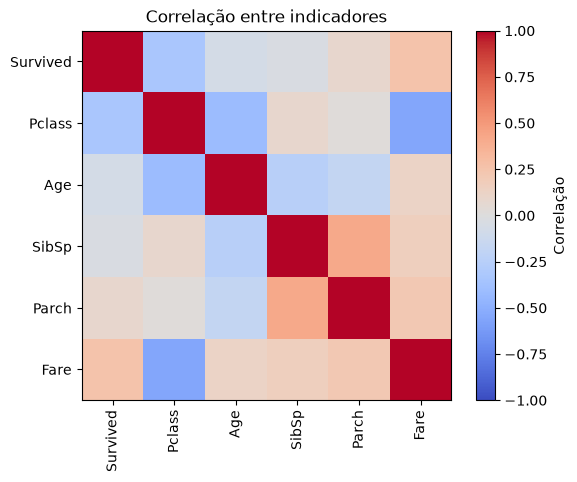

In [ ]:
fig, ax = plt.subplots()

colunas = [
    "Survived",
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
]

# Função nativa do pandas de correlação que retorna um dataframe
correlacoes = df[colunas].corr()

# Usa o imshow de heatmap
imagem = ax.imshow(correlacoes, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_title("Correlação entre indicadores")
ax.set_xticks(range(len(colunas)), colunas, rotation=90)
ax.set_yticks(range(len(colunas)), colunas)

# Legenda em forma de colorbar.
fig.colorbar(imagem, ax=ax, label="Correlação")
plt.show()

# OBS: nesse caso dava pra usar o gênero também, se previamente transformasse ele em 0 e 1. Isso se chama Label Encoding.

### **# Boxplot:**
- Serve pra olhar a distribuição das variáveis (numéricas).
- Separado em quartis.
- Ajuda a identificar a dispersão dos dados e a presença de outliers.

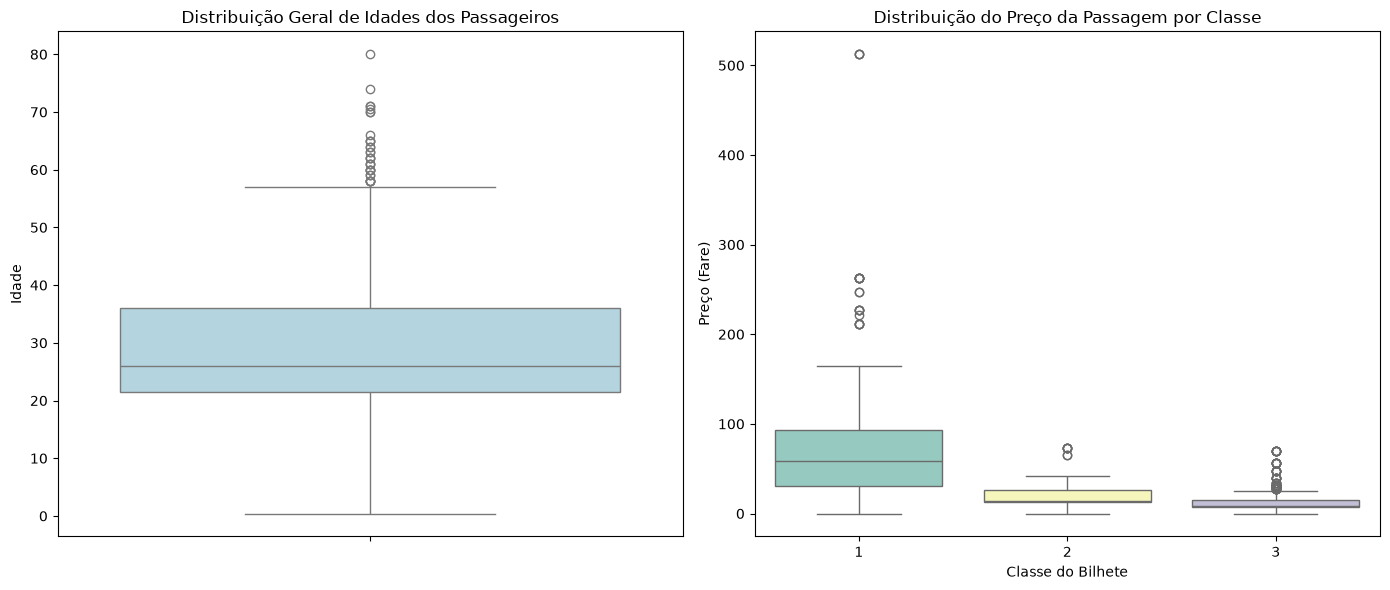

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), layout="tight")

# Boxplot da distribuição geral de Idades
sns.boxplot(ax=axes[0], y="Age", data=df, color="lightblue")
axes[0].set_title("Distribuição Geral de Idades dos Passageiros")
axes[0].set_ylabel("Idade")

# Boxplot do Preço da Passagem (Fare) por Classe (Pclass)
# Útil para notar como os preços da 1ª classe variam drasticamente (outliers no topo)
sns.boxplot(ax=axes[1], x="Pclass", y="Fare", data=df, hue="Pclass", palette="Set3", legend=False)
axes[1].set_title("Distribuição do Preço da Passagem por Classe")
axes[1].set_xlabel("Classe do Bilhete")
axes[1].set_ylabel("Preço (Fare)")

plt.show()